# Attention-head probing and causal tracing in a character-level GPT

This notebook takes the trained 4-layer, 4-head GPT — the full architecture from `progression/04_full_gpt.ipynb`, trained to convergence (30k steps, val 1.65) — and asks a single question: **how does this model decide the next character, and which of its 16 attention heads do the work?**

Four analyses, two correlational and two causal, are run on the same checkpoint:

| # | Analysis | Type | What it answers |
|---|----------|------|------------------|
| 1 | Attention-pattern characterization | correlational | *what* does each head attend to? |
| 2 | Head ablation | causal (coarse) | *how much* does each head matter? |
| 3 | Activation patching | causal (fine) | *where* does information flow? |
| 4 | Residual-stream + logit lens | descriptive | *how* does the prediction form with depth? |

The split between correlational and causal is load-bearing, and this model makes the point concrete: it has **two** sharp previous-token heads by attention, but only **one** of them turns out to matter when you intervene. An attention map shows where a head looks; it does not show that the head's output changes the prediction. Analyses 2 and 3 settle that by intervening on the network and measuring the effect on the loss.

## Setup

Load the committed checkpoint and a fixed held-out evaluation set. Every analysis draws from fixed-seed generators, so the numbers reproduce across runs and machines.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np, torch, matplotlib.pyplot as plt
from models import GPT
from gpt import make_dataset
from gpt.analysis import (eval_batches, attention_summary, classify_head,
                          head_ablation, activation_patching, residual_profile)

model = GPT.from_pretrained(os.path.abspath(os.path.join(os.getcwd(), '..', 'assets', 'gpt.pth')))
ds = make_dataset()
T = model.config.block_size
batches = eval_batches(ds, T, 32, 16)   # 16 batches x 32 = 512 held-out sequences
print(f'{model.num_params()/1e6:.6f}M params | {model.config.n_layer} layers x {model.config.n_head} heads | block {T}')

0.209729M params | 4 layers x 4 heads | block 32


## 1. Attention-pattern characterization (correlational)

**Method.** Run the model over 512 validation sequences with attention capture on, average each head's attention matrix, and summarize each head with five statistics computed per query position (excluding position 0, which is forced to attend to itself):

* **prev** — average weight on the immediately preceding token (sub-diagonal);
* **first** — average weight on position 0 (an attention-sink / start signal);
* **self** — average weight on the current token (diagonal);
* **dist** — mean attended-to distance into the past;
* **entropy** — diffuseness of the attention distribution (low = sharp).

A head with `prev ≈ 1` and near-zero entropy is a clean previous-token head. These labels describe a dominant *tendency*, not a proven function — that is what the interventions in sections 2–3 are for.

In [2]:
mean_maps, stats = attention_summary(model, batches)
print(f"{'L.H':>4} {'prev':>6} {'first':>6} {'self':>6} {'dist':>6} {'entropy':>8}  label")
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        s = stats[(l, h)]
        print(f"{l}.{h:>2} {s['prev']:6.3f} {s['first']:6.3f} {s['self']:6.3f} "
              f"{s['dist']:6.2f} {s['entropy']:8.3f}  {classify_head(s)}")

 L.H   prev  first   self   dist  entropy  label
0. 0  0.095  0.103  0.099   7.93    2.622  diffuse / long-range
0. 1  0.132  0.093  0.082   6.63    2.502  diffuse / long-range
0. 2  0.104  0.101  0.094   7.74    2.617  diffuse / long-range
0. 3  0.819  0.042  0.029   1.73    0.793  previous-token
1. 0  0.396  0.046  0.147   1.65    0.984  previous-token
1. 1  0.980  0.034  0.003   1.07    0.089  previous-token
1. 2  0.419  0.044  0.141   1.73    1.017  previous-token
1. 3  0.356  0.041  0.209   1.57    0.989  previous-token
2. 0  0.304  0.038  0.225   1.93    0.995  local (short-range)
2. 1  0.307  0.048  0.211   2.41    1.126  diffuse / long-range
2. 2  0.439  0.041  0.216   1.69    0.761  previous-token
2. 3  0.373  0.043  0.216   1.60    0.621  previous-token
3. 0  0.282  0.034  0.339   1.81    0.848  local (short-range)
3. 1  0.322  0.043  0.283   2.01    0.955  diffuse / long-range
3. 2  0.228  0.063  0.193   3.64    1.327  diffuse / long-range
3. 3  0.297  0.043  0.254   2.23   

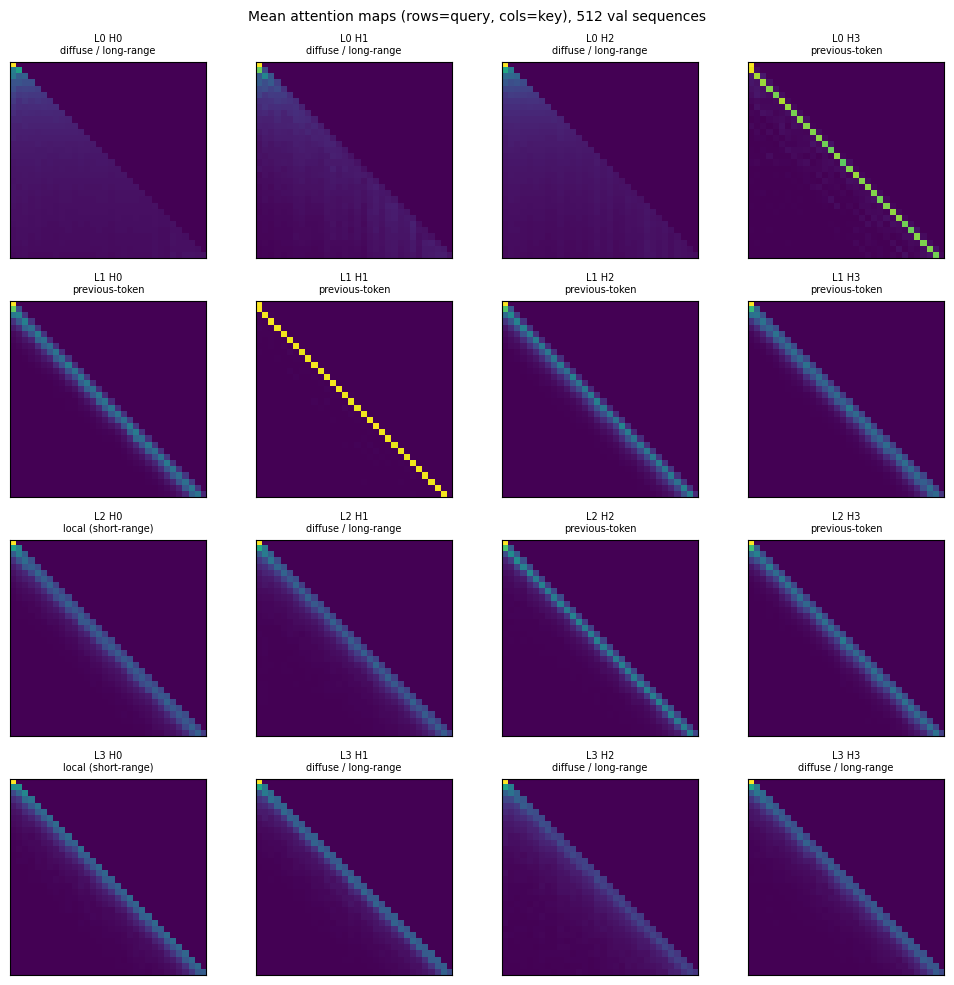

In [3]:
fig, axes = plt.subplots(model.config.n_layer, model.config.n_head, figsize=(10, 10))
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        ax = axes[l, h]
        ax.imshow(mean_maps[l, h].numpy(), cmap='viridis')
        ax.set_title(f'L{l} H{h}\n{classify_head(stats[(l,h)])}', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Mean attention maps (rows=query, cols=key), 512 val sequences', fontsize=10)
fig.tight_layout()
fig.savefig('../assets/attention_grid.png', dpi=120, bbox_inches='tight')
plt.show()

**Findings.** The 16 heads sort by depth, and the converged model has two strikingly sharp previous-token heads:

* **Layer 0 is mostly diffuse, with one sharp exception.** Three heads spread attention broadly (entropy ≈ 2.5–2.6, mean distance ≈ 7–8). The fourth, **L0 H3, is a strong previous-token head: prev ≈ 0.82, entropy ≈ 0.79.** (In the under-trained 5k-step model this head was only weakly previous-token at prev ≈ 0.45 — it sharpened substantially as training continued.)
* **Layer 1 is the previous-token layer.** All four heads lean on the preceding token, and **L1 H1 is a near-perfect previous-token head: prev ≈ 0.98, entropy ≈ 0.09, mean distance ≈ 1.07.** Its map is a single bright sub-diagonal — the cleanest head in the model.
* **Layers 2–3 do shorter-range, more self-weighted mixing,** with self-weight climbing toward ≈ 0.34 (L3 H0) as sharp previous-token structure fades.

So **two** heads — L0 H3 and L1 H1 — look like previous-token heads. The next section asks whether both actually matter, and the answer separates them.

## 2. Head ablation (causal, coarse)

**Method.** Zero one head's contribution at a time — replacing its output with zeros before the attention output projection — and measure the increase in mean validation loss over the same 512 sequences. A large Δloss means the model's predictions depend on that head; a near-zero Δloss means the head is, at the margin and with every other head intact, close to dead weight.

In [4]:
base, delta = head_ablation(model, ds, batches)
print(f'base val loss (analysis eval set): {base:.4f}\n')
for l in range(model.config.n_layer):
    print(' '.join(f'L{l}H{h}:{delta[l,h]:+.4f}' for h in range(model.config.n_head)))
order = sorted(((delta[l,h], l, h) for l in range(model.config.n_layer)
                for h in range(model.config.n_head)), reverse=True)
print('\ntop-5 by importance:', [(f'L{l}H{h}', round(d,4)) for d,l,h in order[:5]])

base val loss (analysis eval set): 1.6668

L0H0:+0.0214 L0H1:-0.0002 L0H2:+0.0159 L0H3:+0.0401
L1H0:+0.0368 L1H1:+0.8853 L1H2:+0.0494 L1H3:+0.0506
L2H0:+0.0594 L2H1:+0.0582 L2H2:+0.0925 L2H3:+0.1259
L3H0:+0.0484 L3H1:+0.0689 L3H2:+0.0280 L3H3:+0.0483

top-5 by importance: [('L1H1', np.float64(0.8853)), ('L2H3', np.float64(0.1259)), ('L2H2', np.float64(0.0925)), ('L3H1', np.float64(0.0689)), ('L2H0', np.float64(0.0594))]


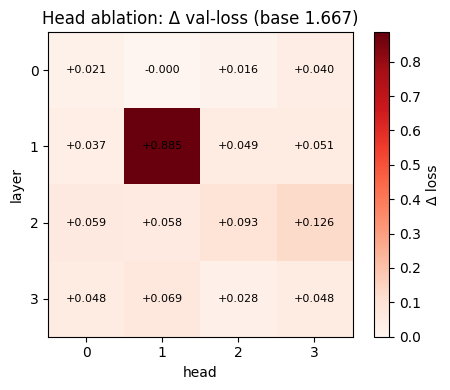

In [5]:
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(delta, cmap='Reds')
ax.set_xlabel('head'); ax.set_ylabel('layer')
ax.set_xticks(range(model.config.n_head)); ax.set_yticks(range(model.config.n_layer))
for l in range(model.config.n_layer):
    for h in range(model.config.n_head):
        ax.text(h, l, f'{delta[l,h]:+.3f}', ha='center', va='center', fontsize=8)
ax.set_title(f'Head ablation: Δ val-loss (base {base:.3f})')
fig.colorbar(im, ax=ax, label='Δ loss'); fig.tight_layout()
fig.savefig('../assets/head_ablation.png', dpi=120, bbox_inches='tight'); plt.show()

**Findings — sharpness is not importance.** One head dominates, and it is not the one you would guess from attention sharpness alone.

* **Ablating L1 H1 raises val loss by ≈ 0.89 nats** — from ≈ 1.67 to ≈ 2.55, more than seven times the next most important head (L2 H3, ≈ 0.13). It is the model's single load-bearing head.
* **L0 H3 — the *other* sharp previous-token head — costs only ≈ 0.04 to ablate.** Nearly as crisp an attention pattern as L1 H1, an order of magnitude less causal importance. The most natural reading is redundancy: L1 H1 supplies a stronger previous-token signal one layer later, so removing L0 H3 on its own barely hurts.
* Layer 0's diffuse heads are free to remove (Δ ≈ 0.00–0.02; L0 H1 is indistinguishable from zero).

This is the clearest single lesson in the notebook: **a head's attention pattern tells you where it looks, not whether the model needs it.** Reading the attention maps alone would have flagged L0 H3 and L1 H1 as co-equal previous-token heads; the intervention shows they are nothing of the kind. The next section traces *how* the head that does matter moves its information.

## 3. Activation patching (causal, fine-grained)

Ablation says a head matters; it does not say what path the information takes. Activation patching traces that path directly.

**Method (interchange intervention).** For each example:

1. Run a **clean** context, record the model's top next-character prediction at the final position and the log-probability it assigns that character, and cache every residual-stream activation.
2. **Corrupt** the token two positions from the end (`T-2`) by replacing it with a random different character, and re-run; the clean prediction's log-probability drops.
3. For each (residual index `k`, position `p`), **patch** the clean activation back into the corrupted run at that one site and re-run, measuring how much of the clean prediction is restored:

$$\text{recovery} = \frac{m_\text{patched} - m_\text{corrupt}}{m_\text{clean} - m_\text{corrupt}}$$

Recovery ≈ 1 means *that site alone carries the corrupted information*. Corrupting near — but not at — the prediction site forces the information to *travel* from `T-2` to `T-1`, so the map reveals **which layer performs that move.** The clean-patch-is-identity invariant this relies on is checked in `tests/test_smoke.py`.

In [6]:
rec, used, cpos = activation_patching(model, ds, n_examples=192)
print(f'corrupt position {cpos}, predict at {T-1}, {used} examples used\n')
labels = ['emb'] + [f'blk{k}' for k in range(model.config.n_layer)]
for k in range(rec.shape[0]):
    print(f'  resid[{k}] ({labels[k]:>4}): ' + '  '.join(f'p{p}:{rec[k,p]:.2f}' for p in range(cpos, T)))

corrupt position 30, predict at 31, 151 examples used

  resid[0] ( emb): p30:1.00  p31:0.00
  resid[1] (blk0): p30:0.96  p31:0.09
  resid[2] (blk1): p30:0.13  p31:0.75
  resid[3] (blk2): p30:0.00  p31:0.90
  resid[4] (blk3): p30:0.00  p31:1.00


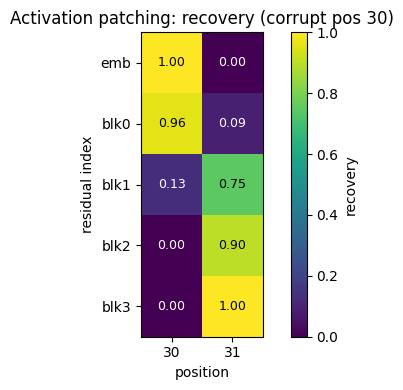

In [7]:
sub = rec[:, cpos:]
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(sub, cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('position'); ax.set_ylabel('residual index')
ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(range(cpos, T))
ax.set_yticks(range(rec.shape[0])); ax.set_yticklabels(labels)
for k in range(rec.shape[0]):
    for j in range(sub.shape[1]):
        ax.text(j, k, f'{sub[k,j]:.2f}', ha='center', va='center',
                color='white' if sub[k,j] < 0.6 else 'black', fontsize=9)
ax.set_title(f'Activation patching: recovery (corrupt pos {cpos})')
fig.colorbar(im, ax=ax, label='recovery'); fig.tight_layout()
fig.savefig('../assets/activation_patching.png', dpi=120, bbox_inches='tight'); plt.show()

**Findings — the handoff.** The recovery map shows a clean handoff between two positions, localized to one layer:

* Through the embedding and block 0 (`resid[0]`, `resid[1]`), recovery sits almost entirely on the **corrupted position** `T-2` (≈ 1.00 / 0.96); patching the prediction position `T-1` recovers little (≈ 0.00 / 0.09). The information is still parked where it entered.
* **After block 1 (`resid[2]`) the picture flips:** patching position `T-1` now recovers ≈ 0.75 while the corrupted position falls to ≈ 0.13. Between the input and output of block 1, the corrupted token's information moved one position forward, into the slot that makes the prediction.
* Blocks 2–3 carry it the rest of the way (≈ 0.90, then ≈ 1.00).

Block 1 is where L1 H1 lives. The patching experiment shows that head's job done causally: it copies the previous token's representation into the current position so the next-character prediction can use it. This is the activation-patching / causal-tracing analysis the makemore repository pointed forward to.

## 4. Residual-stream growth and the logit lens (descriptive)

**Method.** Two measurements per depth `k`: the mean L2 **norm** of the residual vector (how much each block writes), and the **logit lens** — apply the *final* LayerNorm and unembedding to the intermediate stream, reading out what the model would predict if it stopped at depth `k`. Its cross-entropy and top-1 accuracy track how sharply the prediction has formed.

In [8]:
norms, ce, acc = residual_profile(model, batches)
labels = ['emb'] + [f'after blk{k}' for k in range(model.config.n_layer)]
for k in range(len(norms)):
    print(f'  k={k} ({labels[k]:>11}): |resid|={norms[k]:6.2f}  logit-lens CE={ce[k]:.4f}  acc={acc[k]:.4f}')

  k=0 (        emb): |resid|=  8.52  logit-lens CE=5.0477  acc=0.0607
  k=1 ( after blk0): |resid|= 10.90  logit-lens CE=4.0952  acc=0.1169
  k=2 ( after blk1): |resid|= 17.79  logit-lens CE=3.1943  acc=0.2080
  k=3 ( after blk2): |resid|= 21.38  logit-lens CE=2.4565  acc=0.3440
  k=4 ( after blk3): |resid|= 45.64  logit-lens CE=1.6668  acc=0.5101


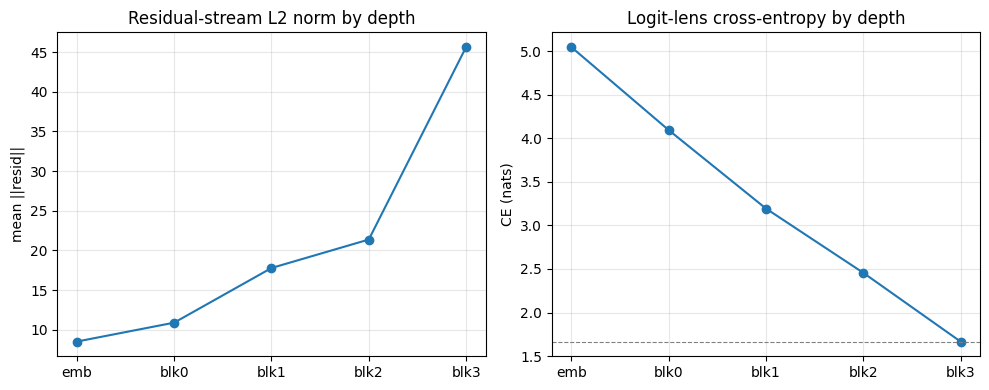

In [9]:
ks = list(range(len(norms))); xl = ['emb'] + [f'blk{k}' for k in range(len(norms)-1)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10,4))
a1.plot(ks, norms, 'o-'); a1.set_title('Residual-stream L2 norm by depth')
a1.set_xticks(ks); a1.set_xticklabels(xl); a1.set_ylabel('mean ||resid||'); a1.grid(alpha=0.3)
a2.plot(ks, ce, 'o-'); a2.set_title('Logit-lens cross-entropy by depth')
a2.set_xticks(ks); a2.set_xticklabels(xl); a2.set_ylabel('CE (nats)'); a2.grid(alpha=0.3)
a2.axhline(ce[-1], ls='--', c='gray', lw=0.8)
fig.tight_layout(); fig.savefig('../assets/residual_logitlens.png', dpi=120, bbox_inches='tight'); plt.show()

**Findings.** The prediction sharpens monotonically with depth: logit-lens top-1 accuracy climbs **0.06 → 0.12 → 0.21 → 0.34 → 0.51**, roughly ten or more points per block, with the final block doing the most. The residual norm grows **8.5 → 10.9 → 17.8 → 21.4 → 45.6**, a large write in the last block. The logit-lens readout at the final depth equals the model's actual loss (≈ 1.67), an internal consistency check that the lens is wired correctly.

One honest wrinkle worth flagging: the **embedding-level** logit-lens cross-entropy here (≈ 5.05) is *worse* than in the under-trained 5k model (≈ 4.31), even though embedding-level accuracy is unchanged (≈ 0.06). As training converges, the token/position embeddings specialize to feed the deeper computation rather than to be read directly by the final unembedding, so the logit lens — which uses that final unembedding — reads them less well. The lens is a *lower bound* on what a layer has computed, not a faithful decoder of it; the early-depth numbers should be read in that light.

## Synthesis: three methods, one head — and one informative near-miss

| Evidence | L1 H1 | L0 H3 |
|----------|-------|-------|
| Attention pattern | sharpest prev-token head (prev ≈ 0.98, entropy ≈ 0.09) | also sharp prev-token (prev ≈ 0.82) |
| Head ablation | most important by 7× (Δloss ≈ 0.89) | nearly free to remove (Δloss ≈ 0.04) |
| Activation patching | block 1 is where prev-token info enters the prediction | — |

A correlational signal, a coarse causal signal, and a fine-grained causal trace converge on **L1 H1**: a previous-token copy operation, concentrated in one head, supplying most of this model's predictive power. That is a coherent story for a character model of Shakespeare, where the largest chunk of predictable structure is local — and it lines up with the progression, where the bigram baseline alone already reaches 2.47 nats and the full model improves to 1.65.

The near-miss is just as useful. **L0 H3 is almost as sharp a previous-token head by attention, yet ablation says the model barely needs it** — the two heads, identical-looking on the attention maps, are an order of magnitude apart in causal importance. The interventions earn their keep precisely here.

## What this shows, and what it does not

**Shows.** A previous-token mechanism dominated by L1 H1 exists, is causally load-bearing (ablation), and operates by moving information from position `t-1` into position `t` at block 1 (patching). A second, attention-equivalent head (L0 H3) is shown *not* to carry comparable causal weight — sharpness and importance come apart.

**Does not show — and three alternative readings of the convergence:**

1. *Task locality, not model depth.* In a corpus where the next character is mostly fixed by the last few characters, almost any importance metric will rank a previous-token head highly. The agreement may reflect the locality of the task as much as a deep fact about this network.
2. *Ablation measures margins, not roles.* The L0 H3 result is itself the caution in action: a head can be near-free to ablate yet still participate, because a redundant downstream head absorbs its removal. The ≈ 0.89 figure for L1 H1 is about its irreplaceability in *this* trained network, not a context-free measure of 'the' previous-token computation.
3. *The patch design favors what it found.* Corrupting at `t-1` and reading at `t` is built to surface a previous-token path; it confirms that path is real and causal but cannot rule out circuitry it was not designed to probe.

**Other limits.** A single training seed; a teaching-scale model whose findings need not transfer to larger ones; and a logit lens that reads intermediate streams through the final unembed — the embedding-CE result above is direct evidence that it under-reads early-layer content.

**Natural next steps.** Separate L1 H1's direct contribution from paths composed through later layers (path patching); read its QK and OV matrices to confirm the copy operation in weight space and to check whether L0 H3 implements the same map; search for induction heads in a model with a longer context than 32; and repeat across seeds to confirm the L1 H1 story is robust rather than an initialization accident.